In [ ]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from pydantic import BaseModel
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnableLambda, RunnableParallel, RunnableBranch
from langchain.agents import create_agent

load_dotenv()

if "OPENAI_API_KEY" not in os.environ:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

llm_openai = ChatOpenAI(model="gpt-5-nano", temperature=0)

from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5:latest",
    temperature=0
)

In [2]:
# Tool - 1: [News Search tools]
from langchain_community.tools import DuckDuckGoSearchResults

search = DuckDuckGoSearchResults()

search.run("Give me the latest news on stocks market on indian markets")



'snippet: Indian stock markets gain this week ahead of Budget ... Markets soar amid value buying in power, banking and metal stocks 3 Jan 2026 8:06 AM IST, title: indian stock market Latest News, indian stock market Breaking, link: https://www.thehansindia.com/tags/indian-stock-market, snippet: The Indian stock markets kicked off the week on a high note despite rising Brent crude prices and geopolitical tensions., title: Indian Markets Surge Amid Global Geopolitical Tensions |, link: https://www.devdiscourse.com/article/business/3888063-indian-markets-surge-amid-global-geopolitical-tensions, snippet: Indian stock indices kicked off the week on a positive note, building on gains from the prior week. ... market actions are leaning towards stock and ..., title: Indian Stock Markets Rise Amid Mixed Global Cues and, link: https://www.devdiscourse.com/article/business/3370490-indian-stock-markets-rise-amid-mixed-global-cues-and-geopolitical-tensions, snippet: Research analyst Richa Agrawal h

In [3]:
# Tool - 2: [Wikipedia Search tools]
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wiki_api = WikipediaAPIWrapper()
wiki = WikipediaQueryRun(api_wrapper=wiki_api)
wiki.run("What is the latest news on AI?")

"Page: Generative AI\nSummary: Generative artificial intelligence, commonly known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code (vibe coding) or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased significantly since the AI boom in the 2020s. This boom was made possible by improvements in deep neural networks, particularly large language models (LLMs), which are based on the transformer architecture. Generative AI applications include chatbots such as ChatGPT, Claude, Copilot, DeepSeek, Google Gemini and Grok; text-to-image models such as DALL-E, Firefly, Stable Diffusion, and Midjourney; and text-to-video models such as Veo, LTX and Sora.\nCompanies in a variety of sect

In [4]:
# Tool - 3: [Custom enterprise tool]

from langchain.tools import tool

@tool
def custom_enterprise_tool(query: str) -> str:
    """This tool to send emails to the enterprise system."""
    # Placeholder implementation - replace with actual enterprise tool logic
    return f"Email sent for query: {query}"




In [5]:
Toolkit = [search, wiki, custom_enterprise_tool]
Toolkit


[DuckDuckGoSearchResults(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\DOMINIC FERNANDES\\Work Station\\python\\langchain_tutorial\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='custom_enterprise_tool', description='This tool to send emails to the enterprise system.', args_schema=<class 'langchain_core.utils.pydantic.custom_enterprise_tool'>, func=<function custom_enterprise_tool at 0x0000024A79CD6480>)]

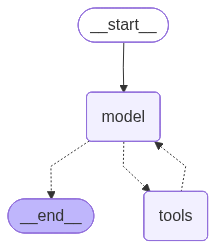

In [6]:
# from langchain.agents import create_agent

# model = ChatOpenAI(
#         model="gpt-5-mini",
#         temperature=0.1,
#         max_tokens=500,
#         timeout=30
#     )

from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5:latest",
    temperature=0
)

agent = create_agent(llm, tools=Toolkit)
agent

# **ReAct agent Invoke with streams**

In [9]:
example_query = "Give me the latest news on stocks market on indian markets."
events = agent.stream(
    {"message": [("user", example_query)]},
    stream_mode="values"
)

for event in events:
    event["message"][-1].pretty_print()

Ollama returned empty response with done_reason='load'.This typically indicates the model was loaded but no content was generated. Skipping this response.


ValueError: No data received from Ollama stream.

In [ ]:
# without binding

llm_openai.invoke("What is the latest news about stocks market on indian markets?")

In [10]:
# with binding
llm_binded = llm.bind_tools(Toolkit)
llm_binded.invoke("What is the latest news about stocks market on indian markets?")


AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5:latest', 'created_at': '2026-05-04T18:51:41.9454561Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12341356600, 'load_duration': 201965800, 'prompt_eval_count': 472, 'prompt_eval_duration': 1033298100, 'eval_count': 128, 'eval_duration': 10897436000, 'logprobs': None, 'model_name': 'qwen3.5:latest', 'model_provider': 'ollama'}, id='lc_run--019df454-c5c2-7920-8fe8-1dccbf293c5a-0', tool_calls=[{'name': 'duckduckgo_results_json', 'args': {'query': 'latest news Indian stock market 2025'}, 'id': 'c16e1ce5-ecf4-4b5b-b028-92c07836d2b1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 472, 'output_tokens': 128, 'total_tokens': 600})